### **Imports**

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent

os.chdir(PROJECT_ROOT)

print(PROJECT_ROOT)

d:\IITG\Projects\audio_factor_disentanglement_v2


In [2]:
import gc
import copy
import random
import time

import numpy as np
import pandas as pd

import torch
import matplotlib.pyplot as plt

from src.utils.config_loader import (
    load_yaml
)

from src.dataset.feature_loader import (
    build_dataloader
)

from src.models.factorized.factorized_vae import (
    FactorizedVAE
)

from src.losses.total_loss import (
    TotalLoss
)

from src.trainers.trainer import (
    Trainer
)

from src.trainers.memory_monitor import (
    MemoryMonitor
)

from src.trainers.beta_scheduler import (
    BetaScheduler
)

from src.trainers.factorvae_scheduler import (
    FactorVAEScheduler
)

from src.trainers.checkpoint_manager import (
    CheckpointManager
)

from src.models.factorized.factor_utils import (
    permute_dims
)

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(
    f"Seed = {SEED}"
)

Seed = 42


### **Configs**

In [4]:
model_cfg = load_yaml(

    PROJECT_ROOT
    /
    "configs"
    /
    "model_config.yaml"
)

train_cfg = load_yaml(

    PROJECT_ROOT
    /
    "configs"
    /
    "train_config.yaml"
)

data_cfg = load_yaml(

    PROJECT_ROOT
    /
    "configs"
    /
    "data_config.yaml"
)

feature_cfg = load_yaml(

    PROJECT_ROOT
    /
    "configs"
    /
    "feature_config.yaml"
)

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"
)

print()

print(
    "Device:",
    device
)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


Device: cpu


In [5]:
merged_cfg = copy.deepcopy(
    model_cfg
)

merged_cfg[
    "staged_activation"
] = train_cfg[
    "staged_activation"
]

merged_cfg[
    "training"
] = train_cfg[
    "training"
]

merged_cfg[
    "gradient"
] = train_cfg[
    "gradient"
]

merged_cfg[
    "mixed_precision"
] = train_cfg[
    "mixed_precision"
]

print()

print(
    "Merged Config Ready"
)

print(
    sorted(
        merged_cfg.keys()
    )
)


Merged Config Ready
['betas', 'factorized_model', 'gradient', 'losses', 'mixed_precision', 'model', 'staged_activation', 'training']


### **Latent Dimension Audit**

In [6]:
latent_cfg = (

    model_cfg[
        "model"
    ][
        "latent_dims"
    ]
)

total_latent = sum(

    latent_cfg.values()
)

print()

for k, v in latent_cfg.items():

    print(

        f"{k:<15}"

        f"{v}"
    )

print()

print(
    f"TOTAL LATENT = "
    f"{total_latent}"
)


content        64
speaker        64
environment    96
excitation     32
fidelity       128

TOTAL LATENT = 384


### **Factor VAE Dimension Check**

In [7]:
expected_dim = (

    latent_cfg["content"]

    +

    latent_cfg["speaker"]

    +

    latent_cfg["environment"]

    +

    latent_cfg["excitation"]

    +

    latent_cfg["fidelity"]
)

print()

print(
    "Expected TC latent dim:",
    expected_dim
)

assert expected_dim == 384


Expected TC latent dim: 384


### **KL Audit**

In [8]:
kl_cfg = (

    model_cfg[
        "losses"
    ][
        "kl"
    ]
)

print()

print(
    "KL Weights"
)

print(
    "-" * 40
)

for k, v in kl_cfg.items():

    print(
        f"{k:<15}"
        f"{v:.6f}"
    )


KL Weights
----------------------------------------
content        0.010000
speaker        0.030000
environment    0.070000
excitation     0.040000
fidelity       0.010000


### **Factor VAE Audit**

In [9]:
factorvae_cfg = (

    model_cfg[
        "losses"
    ][
        "factorvae"
    ]
)

print()

print(
    "TC Gamma:"
)

print(
    factorvae_cfg[
        "gamma"
    ]
)


TC Gamma:
1.0


### **Staged Activation Audit**

In [10]:
stage_cfg = (

    train_cfg[
        "staged_activation"
    ]
)

print()

for k, v in stage_cfg.items():

    print(
        f"{k:<25}"
        f"{v}"
    )


enabled                  True
phase_start              0.05
kl_start                 0.15
orthogonality_start      0.35
tc_start                 0.5


### **Beta Scheduler Preview**

In [11]:
scheduler = BetaScheduler(
    PROJECT_ROOT
)

epochs = np.arange(
    1,
    301
)

content_beta = []
environment_beta = []
excitation_beta = []

for epoch in epochs:

    beta_dict = (
        scheduler
        .get_beta_dict(epoch)
    )

    content_beta.append(
        beta_dict["content"]
    )

    environment_beta.append(
        beta_dict["environment"]
    )

    excitation_beta.append(
        beta_dict["excitation"]
    )

### **Beta Schedules Plot**

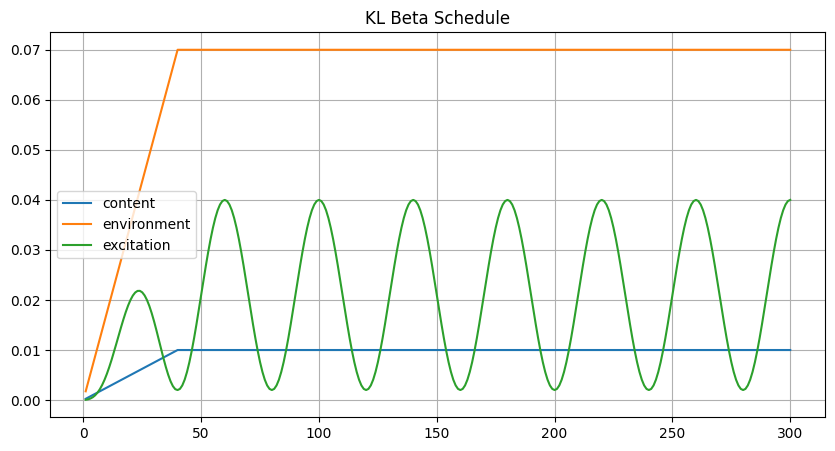

In [12]:
plt.figure(
    figsize=(10,5)
)

plt.plot(

    epochs,

    content_beta,

    label="content"
)

plt.plot(

    epochs,

    environment_beta,

    label="environment"
)

plt.plot(

    epochs,

    excitation_beta,

    label="excitation"
)

plt.legend()

plt.grid(True)

plt.title(
    "KL Beta Schedule"
)

plt.show()

### **Memory Monitor**

In [13]:
monitor = MemoryMonitor()

print()

print(
    "RAM:",
    monitor.get_ram_gb(),
    "GB"
)

if torch.cuda.is_available():

    print()

    print(

        "GPU Allocated:",

        round(
            torch.cuda.memory_allocated()
            /
            1024**3,
            3
        ),

        "GB"
    )


RAM: 0.2871589660644531 GB


### **Feature Inventory**

In [14]:
inventory_path = (

    PROJECT_ROOT
    /
    "data"
    /
    "metadata"
    /
    "feature_inventory_v2.csv"
)

inventory = pd.read_csv(
    inventory_path
)

print()

print(
    inventory.shape
)

display(
    inventory.head()
)


(311, 34)


,speaker,condition,split,source_file,fragment_id,position_index,vad_region_index,start_sample,end_sample,start_time,...,modgd_shape,logmel_shape,mr_mag_256_shape,mr_phase_256_shape,mr_mag_512_shape,mr_phase_512_shape,mr_mag_1024_shape,mr_phase_1024_shape,available_features,sample_rate
0,s1,clean,val,s1_clean_01.wav,0,0,0,10752,13056,0.672,...,"[513, 37]","[80, 37]","[129, 73]","[129, 73]","[257, 37]","[257, 37]","[513, 19]","[513, 19]","['if', 'logmel', 'magnitude', 'modgd', 'mr_mag...",16000
1,s1,clean,train,s1_clean_01.wav,1,1,0,13056,17408,0.816,...,"[513, 69]","[80, 69]","[129, 137]","[129, 137]","[257, 69]","[257, 69]","[513, 35]","[513, 35]","['if', 'logmel', 'magnitude', 'modgd', 'mr_mag...",16000
2,s1,clean,train,s1_clean_01.wav,2,2,1,18432,21888,1.152,...,"[513, 55]","[80, 55]","[129, 109]","[129, 109]","[257, 55]","[257, 55]","[513, 28]","[513, 28]","['if', 'logmel', 'magnitude', 'modgd', 'mr_mag...",16000
3,s1,clean,train,s1_clean_01.wav,3,3,1,21888,23552,1.368,...,"[513, 27]","[80, 27]","[129, 53]","[129, 53]","[257, 27]","[257, 27]","[513, 14]","[513, 14]","['if', 'logmel', 'magnitude', 'modgd', 'mr_mag...",16000
4,s1,clean,train,s1_clean_01.wav,4,4,1,23552,25088,1.472,...,"[513, 25]","[80, 25]","[129, 49]","[129, 49]","[257, 25]","[257, 25]","[513, 13]","[513, 13]","['if', 'logmel', 'magnitude', 'modgd', 'mr_mag...",16000


In [15]:
print()

print(
    inventory["split"]
    .value_counts()
)

print()

if "speaker" in inventory.columns:

    display(

        pd.crosstab(

            inventory["speaker"],

            inventory["split"]
        )
    )

if "condition" in inventory.columns:

    display(

        pd.crosstab(

            inventory["condition"],

            inventory["split"]
        )
    )


split
train    265
val       46
Name: count, dtype: int64



split,train,val
speaker,,
s1,120,21
s2,145,25


split,train,val
condition,,
clean,110,19
noisy,155,27


### **Dataloaders**

In [16]:
train_loader = build_dataloader(

    PROJECT_ROOT,

    split="train"
)

val_loader = build_dataloader(

    PROJECT_ROOT,

    split="val"
)

print()

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Val batches:",
    len(val_loader)
)


Train batches: 64
Val batches: 12


### **Dataset Object** 

In [17]:
train_dataset = train_loader.dataset

print()

print(
    "Dataset length:",
    len(train_dataset)
)

print()

print(
    type(train_dataset)
)


Dataset length: 265

<class 'src.dataset.feature_dataset.FeatureDataset'>


### **One Raw Sample**

In [18]:
sample = train_dataset[0]

print()

print(
    type(sample)
)

print()

print(
    sample.keys()
)


<class 'dict'>

dict_keys(['logmel', 'mr_mag_256', 'mr_mag_512', 'mr_mag_1024', 'magnitude', 'if', 'modgd', 'phase_sin', 'phase_cos', 'length', 'speaker', 'condition', 'split', 'fragment_id', 'source_file', 'relative_position'])


### **Feature Shape**

In [19]:
import pandas as pd
import numpy as np

rows = []

for name, value in sample.items():

    if torch.is_tensor(value):

        arr = value.numpy()

        rows.append({

            "feature":
                name,

            "shape":
                tuple(arr.shape),

            "dtype":
                arr.dtype,

            "min":
                float(arr.min()),

            "max":
                float(arr.max()),

            "mean":
                float(arr.mean()),

            "std":
                float(arr.std())
        })

audit_df = pd.DataFrame(
    rows
)

display(
    audit_df
)

,feature,shape,dtype,min,max,mean,std
0,logmel,"(80, 69)",float32,0.00000,1.00000,0.403983,0.251071
1,mr_mag_256,"(129, 137)",float32,0.00000,1.00000,0.255950,0.236850
2,mr_mag_512,"(257, 69)",float32,0.00000,1.00000,0.254838,0.230516
3,mr_mag_1024,"(513, 35)",float32,0.00000,1.00000,0.227005,0.218705
4,magnitude,"(513, 69)",float32,0.00000,1.00000,0.225314,0.218511
5,if,"(513, 69)",float32,-2.00199,2.00199,0.005270,1.156813
6,modgd,"(513, 69)",float32,-1.00000,1.00000,0.032119,0.945880
7,phase_sin,"(513, 69)",float32,-1.00000,1.00000,-0.000164,0.705186
8,phase_cos,"(513, 69)",float32,-1.00000,1.00000,0.002019,0.709019


### **Explicit Shape Verification**

In [20]:
expected_freq_bins = {

    "logmel":80,

    "mr_mag_256":129,

    "mr_mag_512":257,

    "mr_mag_1024":513,

    "magnitude":513,

    "if":513,

    "modgd":513,

    "phase_sin":513,

    "phase_cos":513
}

for feature, freq in expected_freq_bins.items():

    tensor = sample[feature]

    print()

    print(
        feature,
        tensor.shape
    )

    assert tensor.shape[-2] == freq


logmel torch.Size([80, 69])

mr_mag_256 torch.Size([129, 137])

mr_mag_512 torch.Size([257, 69])

mr_mag_1024 torch.Size([513, 35])

magnitude torch.Size([513, 69])

if torch.Size([513, 69])

modgd torch.Size([513, 69])

phase_sin torch.Size([513, 69])

phase_cos torch.Size([513, 69])


In [21]:
for feature, tensor in sample.items():

    if not torch.is_tensor(
        tensor
    ):
        continue

    nan_count = torch.isnan(
        tensor
    ).sum()

    inf_count = torch.isinf(
        tensor
    ).sum()

    print(

        f"{feature:<15}",

        f"nan={nan_count.item():<5}",

        f"inf={inf_count.item():<5}"
    )

logmel          nan=0     inf=0    
mr_mag_256      nan=0     inf=0    
mr_mag_512      nan=0     inf=0    
mr_mag_1024     nan=0     inf=0    
magnitude       nan=0     inf=0    
if              nan=0     inf=0    
modgd           nan=0     inf=0    
phase_sin       nan=0     inf=0    
phase_cos       nan=0     inf=0    


### **Core Features**

In [22]:
features_to_plot = [

    "logmel",

    "magnitude",

    "if",

    "modgd",

    "phase_sin",

    "phase_cos"
]

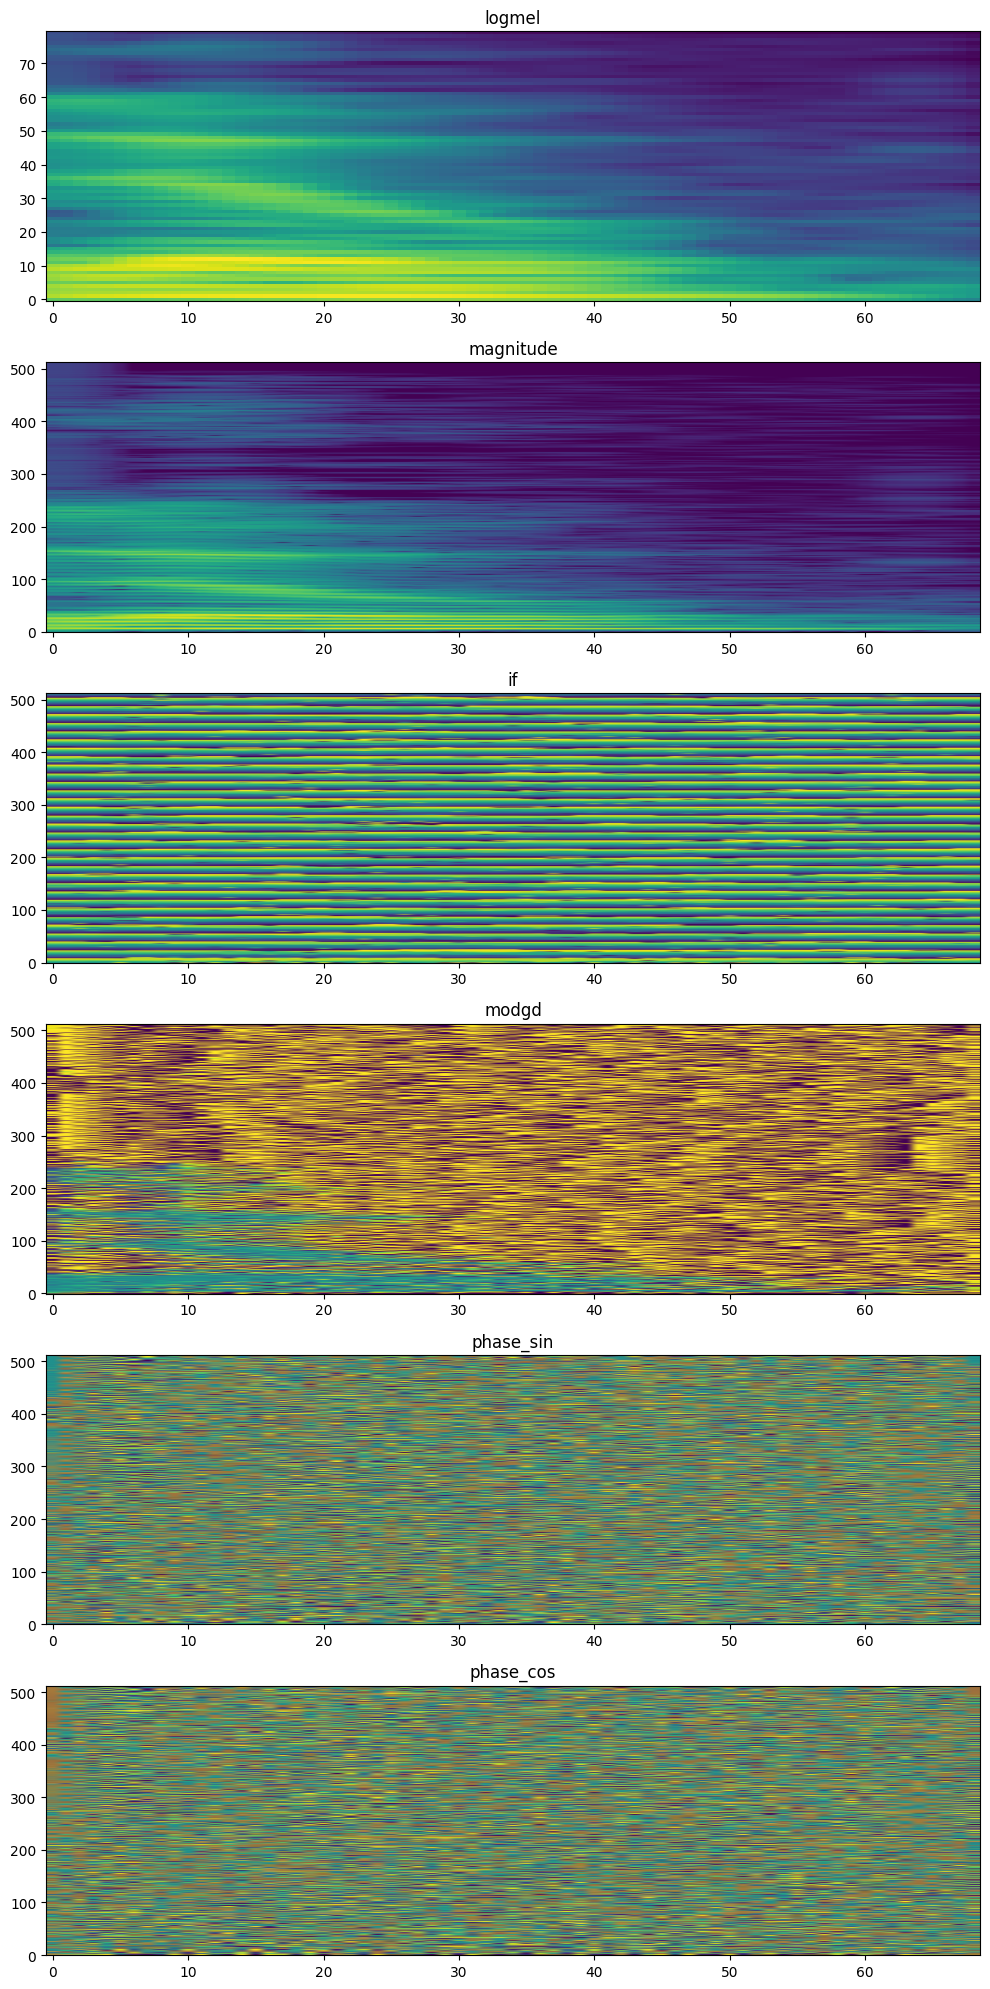

In [23]:
fig, axes = plt.subplots(

    len(features_to_plot),

    1,

    figsize=(10,20)
)

for ax, feature in zip(

    axes,

    features_to_plot
):

    image = sample[
        feature
    ]

    if image.ndim == 3:

        image = image[0]

    ax.imshow(

        image,

        aspect="auto",

        origin="lower"
    )

    ax.set_title(
        feature
    )

plt.tight_layout()

plt.show()

### **MRA Consistency**

In [24]:
for feature in [

    "mr_mag_256",

    "mr_mag_512",

    "mr_mag_1024"
]:

    tensor = sample[
        feature
    ]

    print(

        feature,

        tensor.shape
    )

mr_mag_256 torch.Size([129, 137])
mr_mag_512 torch.Size([257, 69])
mr_mag_1024 torch.Size([513, 35])


### **Single Batch Retrieval**

In [25]:
batch = next(

    iter(
        train_loader
    )
)

print()

print(
    batch.keys()
)


dict_keys(['logmel', 'mr_mag_256', 'mr_mag_512', 'mr_mag_1024', 'magnitude', 'if', 'modgd', 'phase_sin', 'phase_cos', 'lengths', 'speaker', 'condition', 'split'])


### **Batch Shape**

In [26]:
for key, value in batch.items():

    if torch.is_tensor(
        value
    ):

        print(

            f"{key:<15}",

            tuple(
                value.shape
            )
        )

logmel          (4, 80, 59)
mr_mag_256      (4, 129, 117)
mr_mag_512      (4, 257, 59)
mr_mag_1024     (4, 513, 30)
magnitude       (4, 513, 59)
if              (4, 513, 59)
modgd           (4, 513, 59)
phase_sin       (4, 513, 59)
phase_cos       (4, 513, 59)
lengths         (4,)


In [27]:
for key, value in batch.items():

    if not torch.is_tensor(
        value
    ):
        continue

    print(

        f"{key:<15}",

        torch.isnan(value)
        .sum()
        .item()
    )

logmel          0
mr_mag_256      0
mr_mag_512      0
mr_mag_1024     0
magnitude       0
if              0
modgd           0
phase_sin       0
phase_cos       0
lengths         0


### **Batch Memory**

In [28]:
total_mb = 0

for key, value in batch.items():

    if torch.is_tensor(
        value
    ):

        mb = (

            value.numel()
            *
            value.element_size()
        ) / 1024**2

        total_mb += mb

        print(

            f"{key:<15}",

            f"{mb:.2f} MB"
        )

print()

print(
    f"Batch Total = {total_mb:.2f} MB"
)

logmel          0.07 MB
mr_mag_256      0.23 MB
mr_mag_512      0.23 MB
mr_mag_1024     0.23 MB
magnitude       0.46 MB
if              0.46 MB
modgd           0.46 MB
phase_sin       0.46 MB
phase_cos       0.46 MB
lengths         0.00 MB

Batch Total = 3.08 MB


### **Dataset Class Balance**

In [29]:
inventory = pd.read_csv(

    PROJECT_ROOT
    /
    "data"
    /
    "metadata"
    /
    "feature_inventory_v2.csv"
)

display(

    inventory[
        "speaker"
    ].value_counts()
)

display(

    inventory[
        "condition"
    ].value_counts()
)

speaker
s2    170
s1    141
Name: count, dtype: int64

condition
noisy    182
clean    129
Name: count, dtype: int64

### **Random Sample Consistancy**

In [30]:
indices = np.random.choice(

    len(train_dataset),

    10,

    replace=False
)

for idx in indices:

    sample = train_dataset[idx]

    print(
        idx
    )

    for feature in [

        "logmel",

        "magnitude",

        "if",

        "modgd"
    ]:

        x = sample[feature]

        print(

            feature,

            tuple(x.shape)
        )

    print(
        "-" * 50
    )

179
logmel (80, 35)
magnitude (513, 35)
if (513, 35)
modgd (513, 35)
--------------------------------------------------
115
logmel (80, 53)
magnitude (513, 53)
if (513, 53)
modgd (513, 53)
--------------------------------------------------
96
logmel (80, 51)
magnitude (513, 51)
if (513, 51)
modgd (513, 51)
--------------------------------------------------
24
logmel (80, 35)
magnitude (513, 35)
if (513, 35)
modgd (513, 35)
--------------------------------------------------
9
logmel (80, 33)
magnitude (513, 33)
if (513, 33)
modgd (513, 33)
--------------------------------------------------
139
logmel (80, 25)
magnitude (513, 25)
if (513, 25)
modgd (513, 25)
--------------------------------------------------
255
logmel (80, 37)
magnitude (513, 37)
if (513, 37)
modgd (513, 37)
--------------------------------------------------
45
logmel (80, 85)
magnitude (513, 85)
if (513, 85)
modgd (513, 85)
--------------------------------------------------
185


logmel (80, 29)
magnitude (513, 29)
if (513, 29)
modgd (513, 29)
--------------------------------------------------
125
logmel (80, 69)
magnitude (513, 69)
if (513, 69)
modgd (513, 69)
--------------------------------------------------


In [31]:
print()

print(
    "Configured batch size:",
    train_cfg["training"]["batch_size"]
)

print(
    "Train loader batch size:",
    train_loader.batch_size
)

print(
    "Val loader batch size:",
    val_loader.batch_size
)


Configured batch size: 4
Train loader batch size: None
Val loader batch size: 4


### **Model**

In [32]:
# C1
# Build Model

model = FactorizedVAE(
    merged_cfg
).to(device)

print(type(model))

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print()
print(
    f"Total Params: {total_params:,}"
)

print(
    f"Trainable Params: {trainable_params:,}"
)

<class 'src.models.factorized.factorized_vae.FactorizedVAE'>

Total Params: 73,217,893
Trainable Params: 73,217,893


### **Single Batch**

In [33]:
# C2
# Single Batch

batch = next(
    iter(train_loader)
)

batch = {

    k:
    v.to(device)

    if torch.is_tensor(v)

    else v

    for k,v in batch.items()
}

print()

for k,v in batch.items():

    if torch.is_tensor(v):

        print(
            f"{k:<15}",
            tuple(v.shape)
        )


logmel          (4, 80, 35)
mr_mag_256      (4, 129, 69)
mr_mag_512      (4, 257, 35)
mr_mag_1024     (4, 513, 18)
magnitude       (4, 513, 35)
if              (4, 513, 35)
modgd           (4, 513, 35)
phase_sin       (4, 513, 35)
phase_cos       (4, 513, 35)
lengths         (4,)


### **Feature Group Manager**

In [34]:
# C3
# Feature Groups

feature_groups = (

    model.group_manager
    .build_groups(batch)
)

print()

for group_name,group in (

    feature_groups.items()
):

    print()
    print(group_name)

    for feature_name,tensor in (

        group.items()
    ):

        print(
            f"  {feature_name:<15}",
            tuple(tensor.shape)
        )



content
  logmel          (4, 1, 80, 35)
  mr_mag_256      (4, 1, 129, 69)
  if              (4, 1, 513, 35)

speaker
  mr_mag_512      (4, 1, 257, 35)
  mr_mag_256      (4, 1, 129, 69)
  logmel          (4, 1, 80, 35)

environment
  magnitude       (4, 1, 513, 35)
  mr_mag_1024     (4, 1, 513, 18)
  if              (4, 1, 513, 35)

excitation
  modgd           (4, 1, 513, 35)

fidelity
  phase_sin       (4, 1, 513, 35)
  phase_cos       (4, 1, 513, 35)
  mr_mag_512      (4, 1, 257, 35)
  mr_mag_1024     (4, 1, 513, 18)
  magnitude       (4, 1, 513, 35)
  modgd           (4, 1, 513, 35)


### **Encoder Outputs**

In [35]:
# C4
# Encoder Verification

latents,mu,logvar = (

    model.encode(
        feature_groups
    )
)

print()

for name in latents:

    print(
        f"{name:<12}",
        "z",
        tuple(
            latents[name].shape
        ),

        "mu",
        tuple(
            mu[name].shape
        ),

        "logvar",
        tuple(
            logvar[name].shape
        )
    )


content      z (4, 64) mu (4, 64) logvar (4, 64)
speaker      z (4, 64) mu (4, 64) logvar (4, 64)
environment  z (4, 96) mu (4, 96) logvar (4, 96)
excitation   z (4, 32) mu (4, 32) logvar (4, 32)
fidelity     z (4, 128) mu (4, 128) logvar (4, 128)


### **Latent Stats**

In [36]:
# C5
# Latent Stats

for name,z in latents.items():

    print()

    print(name)

    print(
        "mean:",
        z.mean().item()
    )

    print(
        "std:",
        z.std().item()
    )

    print(
        "min:",
        z.min().item()
    )

    print(
        "max:",
        z.max().item()
    )


content
mean: -0.018838506191968918
std: 1.0548889636993408
min: -3.3883116245269775
max: 2.850302219390869

speaker
mean: 0.020698808133602142
std: 1.1171010732650757
min: -3.1606640815734863
max: 3.071833610534668

environment
mean: -0.031821269541978836
std: 1.1933084726333618
min: -4.796487808227539
max: 3.4754583835601807

excitation
mean: -0.17568407952785492
std: 1.114099383354187
min: -3.1717734336853027
max: 2.886493444442749

fidelity
mean: 0.028744708746671677
std: 1.1380014419555664
min: -3.983293056488037
max: 3.326051950454712


### **Joint Latent**

In [37]:
# C6
# Joint Latent

joint_latent = (

    model.build_joint_latent(
        latents
    )
)

print(
    joint_latent.shape
)

print(
    "Expected latent dim:",
    64 + 64 + 96 + 32 + 128
)

torch.Size([4, 384])
Expected latent dim: 384


### **TC Discriminator**

In [38]:
# C7
# FactorVAE Discriminator Audit

from src.models.factorized.factorvae_discriminator import (
    FactorVAEDiscriminator
)

latent_dim = joint_latent.shape[-1]

disc = FactorVAEDiscriminator(
    latent_dim=latent_dim
).to(device)

with torch.no_grad():

    logits = disc(
        joint_latent
    )

print(
    "Joint latent:",
    tuple(joint_latent.shape)
)

print(
    "Discriminator logits:",
    tuple(logits.shape)
)

print(
    "Expected:",
    (joint_latent.shape[0], 2)
)

Joint latent: (4, 384)
Discriminator logits: (4, 2)
Expected: (4, 2)


In [39]:
# C7.1 Permutation Audit

from src.models.factorized.factor_utils import (
    permute_dims
)

z_perm = permute_dims(
    joint_latent
)

print(
    "Original:",
    tuple(joint_latent.shape)
)

print(
    "Permuted:",
    tuple(z_perm.shape)
)

print(
    "Equal:",
    torch.equal(
        joint_latent,
        z_perm
    )
)

Original: (4, 384)
Permuted: (4, 384)
Equal: False


In [40]:
# C7.2 FactorVAE Loss Audit

from src.losses.factorvae_loss import (
    FactorVAELoss
)

loss_module = FactorVAELoss(
    gamma=5.0
)

real_logits = disc(
    joint_latent
)

perm_logits = disc(
    z_perm
)

loss_dict = loss_module(

    real_logits,

    perm_logits
)

for k,v in loss_dict.items():

    print(
        k,
        float(v)
    )

tc_loss 0.0
tc_estimate 0.08408158272504807
tc_scale 0.0
discriminator_loss 0.6898719072341919


C:\Users\Dell\AppData\Local\Temp\ipykernel_12016\514406072.py:30: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  float(v)


In [41]:
# C8
# Decoder Core

target_lengths = {

    "logmel":
        batch["logmel"].shape[-1],

    "mr_mag_256":
        batch["mr_mag_256"].shape[-1],

    "mr_mag_512":
        batch["mr_mag_512"].shape[-1],

    "magnitude":
        batch["magnitude"].shape[-1],

    "mr_mag_1024":
        batch["mr_mag_1024"].shape[-1]
}

hidden = (

    model.decoder_core(

        latents["content"],

        latents["speaker"],

        latents["environment"],

        latents["excitation"],

        latents["fidelity"],

        target_lengths[
            "logmel"
        ]
    )
)

print(
    hidden.shape
)

torch.Size([4, 35, 256])


In [42]:
# C9
# Decoder Outputs

recons = (

    model.decode(

        latents,

        target_lengths
    )
)

print()

for k,v in recons.items():

    print(
        f"{k:<15}",
        tuple(v.shape)
    )


logmel          (4, 80, 35)
mr_mag_256      (4, 129, 69)
mr_mag_512      (4, 257, 35)
magnitude       (4, 513, 35)
mr_mag_1024     (4, 513, 18)
if              (4, 513, 35)
modgd           (4, 513, 35)
phase_sin       (4, 513, 35)
phase_cos       (4, 513, 35)


In [43]:
# C10
# Full Forward Pass

outputs = model(batch)

print()

for k,v in outputs.items():

    if torch.is_tensor(v):

        print(
            k,
            tuple(v.shape)
        )

    elif isinstance(v,dict):

        print()
        print(k)

        for kk,vv in v.items():

            if torch.is_tensor(vv):

                print(
                    f"  {kk:<15}",
                    tuple(vv.shape)
                )



groups

latents
  content         (4, 64)
  speaker         (4, 64)
  environment     (4, 96)
  excitation      (4, 32)
  fidelity        (4, 128)

mu
  content         (4, 64)
  speaker         (4, 64)
  environment     (4, 96)
  excitation      (4, 32)
  fidelity        (4, 128)

logvar
  content         (4, 64)
  speaker         (4, 64)
  environment     (4, 96)
  excitation      (4, 32)
  fidelity        (4, 128)

reconstructions
  logmel          (4, 80, 35)
  mr_mag_256      (4, 129, 69)
  mr_mag_512      (4, 257, 35)
  magnitude       (4, 513, 35)
  mr_mag_1024     (4, 513, 18)
  if              (4, 513, 35)
  modgd           (4, 513, 35)
  phase_sin       (4, 513, 35)
  phase_cos       (4, 513, 35)
joint_latent (4, 384)


In [44]:
# C11
# Numerical Audit

def check_tensor(name,x):

    print(
        f"{name:<20}",
        "nan=",
        torch.isnan(x).sum().item(),

        "inf=",
        torch.isinf(x).sum().item()
    )

for group in [

    "latents",
    "mu",
    "logvar"
]:

    print()
    print(group)

    for name,tensor in (

        outputs[group]
        .items()
    ):

        check_tensor(
            name,
            tensor
        )


latents
content              nan= 0 inf= 0
speaker              nan= 0 inf= 0
environment          nan= 0 inf= 0
excitation           nan= 0 inf= 0
fidelity             nan= 0 inf= 0

mu
content              nan= 0 inf= 0
speaker              nan= 0 inf= 0
environment          nan= 0 inf= 0
excitation           nan= 0 inf= 0
fidelity             nan= 0 inf= 0

logvar
content              nan= 0 inf= 0
speaker              nan= 0 inf= 0
environment          nan= 0 inf= 0
excitation           nan= 0 inf= 0
fidelity             nan= 0 inf= 0


### **LOSS VERIFICATION**

In [45]:
# Instantiate Loss

from src.losses.total_loss import (
    TotalLoss
)

loss_fn = TotalLoss(
    merged_cfg
)

print(type(loss_fn))

<class 'src.losses.total_loss.TotalLoss'>


In [46]:
# Full Loss Forward Pass

outputs = model(batch)

loss_dict = loss_fn(
    outputs,
    batch
)

print()

for k,v in loss_dict.items():

    if torch.is_tensor(v):

        print(
            f"{k:<25}",
            float(v.detach())
        )

    else:

        print(
            f"{k:<25}",
            v
        )


[LOSS ACTIVATION STATE]
epoch=0
progress=0.0000
phase=False
kl=False
orthogonality=False
tc=False

[PHASE ACTIVATION]
epoch=0
progress=0.0000
enabled=False

reconstruction            5.682053089141846
phase_enabled             0.0
phase_progress            0.0
logmel_loss               0.24668428301811218
logmel_l1                 0.21312172710895538
logmel_mse                0.067125104367733
mr_mag_256_loss           0.2796357572078705
mr_mag_256_l1             0.2386598438024521
mr_mag_256_mse            0.08195183426141739
mr_mag_512_loss           0.2883146405220032
mr_mag_512_l1             0.24556899070739746
mr_mag_512_mse            0.08549126982688904
magnitude_loss            0.2902800440788269
magnitude_l1              0.24722450971603394
magnitude_mse             0.08611109107732773
mr_mag_1024_loss          0.28793230652809143
mr_mag_1024_l1            0.24538110196590424
mr_mag_1024_mse           0.08510242402553558
if_loss                   1.5110485553741455
if_l1    

In [47]:
# KL Audit

kl_keys = [

    k

    for k in loss_dict.keys()

    if "kl" in k.lower()
]

for k in kl_keys:

    print(
        k,
        float(
            loss_dict[k].detach()
        )
    )

content_kl 0.0
speaker_kl 0.0
environment_kl 0.0
excitation_kl 0.0
fidelity_kl 0.0
kl_total 0.0


In [48]:
# Orthogonality Audit

lat = outputs["latents"]

for k,v in lat.items():

    print(
        k,
        tuple(v.shape)
    )

content (4, 64)
speaker (4, 64)
environment (4, 96)
excitation (4, 32)
fidelity (4, 128)


In [49]:
joint = outputs["joint_latent"]

corr = torch.corrcoef(
    joint.T
)

print(
    corr.shape
)

torch.Size([384, 384])


In [50]:
# TC Audit

from src.losses.factorvae_loss import (
    FactorVAELoss
)

tc_module = FactorVAELoss(
    gamma=5.0
)

real_logits = disc(
    joint_latent
)

perm_logits = disc(
    z_perm
)

tc_result = tc_module(

    real_logits,

    perm_logits
)

for k,v in tc_result.items():

    print(
        k,
        float(v.detach())
    )

tc_loss 0.0
tc_estimate 0.08408158272504807
tc_scale 0.0
discriminator_loss 0.6898719072341919


In [51]:
from src.models.factorized.factorvae_discriminator import (
    FactorVAEDiscriminator
)

disc = FactorVAEDiscriminator(
    latent_dim=384
).to(device)

real_logits = disc(
    joint_latent
)

perm_logits = disc(
    z_perm
)

print(real_logits.shape)
print(perm_logits.shape)

torch.Size([4, 2])
torch.Size([4, 2])


In [52]:
# Full Backward Pass

model.zero_grad()

loss_dict = loss_fn(
    outputs,
    batch
)

loss = loss_dict["total"]
loss.backward()

In [53]:
# Inspect Gradients

max_grad = 0.0
mean_grad = []

nan_count = 0

for p in model.parameters():

    if p.grad is None:
        continue

    g = p.grad.detach()

    if torch.isnan(g).any():
        nan_count += 1

    max_grad = max(
        max_grad,
        g.abs().max().item()
    )

    mean_grad.append(
        g.abs().mean().item()
    )

print(
    "Max Grad:",
    max_grad
)

print(
    "Mean Grad:",
    sum(mean_grad)/len(mean_grad)
)

print(
    "NaN Grad Tensors:",
    nan_count
)

Max Grad: 0.024295255541801453
Mean Grad: 3.911991163090338e-05
NaN Grad Tensors: 0


In [54]:
from src.trainers.factorvae_scheduler import (
    FactorVAEScheduler
)

factorvae_scheduler = (
    FactorVAEScheduler(
        project_root=PROJECT_ROOT,
        model=model,
        device=device
    )
)

In [55]:
outputs = model(batch)

tc_outputs = (
    factorvae_scheduler
    .generator_logits(
        outputs["joint_latent"]
    )
)

outputs["tc_logits"] = (
    tc_outputs["real"]
)

outputs["tc_logits_permuted"] = (
    tc_outputs["permuted"]
)

loss_fn.current_epoch = 200
loss_fn.total_epochs = 200

loss_dict = loss_fn(
    outputs,
    batch
)

print(
    "TC:",
    float(loss_dict["tc"].detach())
)


[LOSS ACTIVATION STATE]
epoch=200
progress=1.0000
phase=True
kl=True
orthogonality=True
tc=True

[PHASE ACTIVATION]
epoch=200
progress=1.0000
enabled=True

[PHASE DIAGNOSTICS]
phase_derivative=0.561489
derived_if=1.087596
derived_gd=1.158359
von_mises=0.250814
phase_continuity=0.093563

[KL DIAGNOSTICS]
content KL=0.115240 BETA=0.010000
speaker KL=0.115006 BETA=0.030000
environment KL=0.106146 BETA=0.070000
excitation KL=0.092239 BETA=0.040000
fidelity KL=0.097876 BETA=0.010000

[ORTHOGONALITY]
loss=0.239854

[TC DIAGNOSTICS]
tc=0.021262
disc=0.691243
TC: 0.02126244269311428


### **Single Batch Overfit Test**

In [56]:
# E1
# Single Fixed Batch

fixed_batch = batch

for k, v in fixed_batch.items():

    if torch.is_tensor(v):

        print(
            f"{k:<15}",
            tuple(v.shape)
        )

logmel          (4, 80, 35)
mr_mag_256      (4, 129, 69)
mr_mag_512      (4, 257, 35)
mr_mag_1024     (4, 513, 18)
magnitude       (4, 513, 35)
if              (4, 513, 35)
modgd           (4, 513, 35)
phase_sin       (4, 513, 35)
phase_cos       (4, 513, 35)
lengths         (4,)


In [57]:
# E2
# Optimizer

import torch.optim as optim

overfit_optimizer = optim.AdamW(

    model.parameters(),

    lr=5e-4,

    weight_decay=0.0
)

print(
    "Optimizer Ready"
)

Optimizer Ready


In [58]:
# E3

loss_fn.current_epoch = 300
loss_fn.total_epochs = 300

factorvae_scheduler = (

    FactorVAEScheduler(

        project_root=PROJECT_ROOT,

        model=model,

        device=device
    )
)

print(
    "All losses enabled"
)

All losses enabled


In [59]:
# E4
# Overfit Single Batch

from collections import defaultdict

history = defaultdict(list)

model.train()

NUM_ITERS = 100

for step in range(NUM_ITERS):

    overfit_optimizer.zero_grad()

    outputs = model(
        fixed_batch
    )

    tc_outputs = (

        factorvae_scheduler
        .generator_logits(

            outputs[
                "joint_latent"
            ]
        )
    )

    outputs[
        "tc_logits"
    ] = tc_outputs[
        "real"
    ]

    outputs[
        "tc_logits_permuted"
    ] = tc_outputs[
        "permuted"
    ]

    loss_dict = loss_fn(

        outputs,

        fixed_batch
    )

    loss = loss_dict[
        "total"
    ]

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        3.0
    )

    overfit_optimizer.step()

    history["total"].append(
        float(loss.detach())
    )

    history["reconstruction"].append(
        float(
            loss_dict[
                "reconstruction"
            ].detach()
        )
    )

    history["kl"].append(
        float(
            loss_dict[
                "kl_total"
            ].detach()
        )
    )

    history["orthogonality"].append(
        float(
            loss_dict[
                "orthogonality"
            ].detach()
        )
    )

    history["tc"].append(
        float(
            loss_dict[
                "tc"
            ].detach()
        )
    )

    if step % 10 == 0:

        print(

            f"Step {step:03d}"

            f" | Total={history['total'][-1]:.4f}"

            f" | Recon={history['reconstruction'][-1]:.4f}"

            f" | KL={history['kl'][-1]:.4f}"

            f" | TC={history['tc'][-1]:.4f}"
        )


[PHASE DIAGNOSTICS]
phase_derivative=0.559456
derived_if=1.088634
derived_gd=1.149191
von_mises=0.249393
phase_continuity=0.093320

[KL DIAGNOSTICS]
content KL=0.122174 BETA=0.010000
speaker KL=0.115262 BETA=0.030000
environment KL=0.106734 BETA=0.070000
excitation KL=0.094166 BETA=0.040000
fidelity KL=0.096327 BETA=0.010000

[ORTHOGONALITY]
loss=0.296891

[TC DIAGNOSTICS]
tc=0.061019
disc=0.694056
Step 000 | Total=8.7762 | Recon=6.5830 | KL=0.0169 | TC=0.0610

[PHASE DIAGNOSTICS]
phase_derivative=0.561129
derived_if=1.085635
derived_gd=1.158883
von_mises=0.250467
phase_continuity=0.093306

[KL DIAGNOSTICS]
content KL=0.161688 BETA=0.010000
speaker KL=0.196782 BETA=0.030000
environment KL=0.136083 BETA=0.070000
excitation KL=0.143965 BETA=0.040000
fidelity KL=0.130175 BETA=0.010000

[ORTHOGONALITY]
loss=0.214949

[TC DIAGNOSTICS]
tc=-0.056870
disc=0.692347

[PHASE DIAGNOSTICS]
phase_derivative=0.558514
derived_if=1.083426
derived_gd=1.150629
von_mises=0.249615
phase_continuity=0.09295

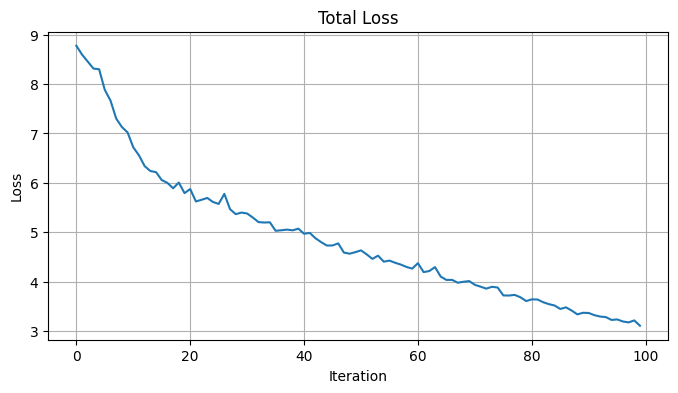

In [60]:
# E5

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(
    history["total"]
)

plt.title(
    "Total Loss"
)

plt.xlabel(
    "Iteration"
)

plt.ylabel(
    "Loss"
)

plt.grid(True)

plt.show()

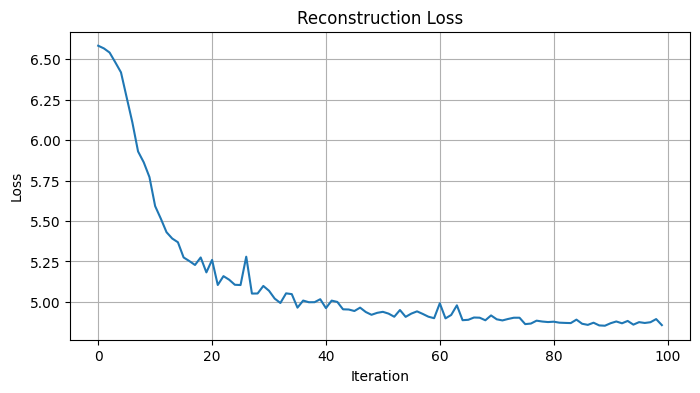

In [61]:
# E6

plt.figure(figsize=(8,4))

plt.plot(
    history["reconstruction"]
)

plt.title(
    "Reconstruction Loss"
)

plt.xlabel(
    "Iteration"
)

plt.ylabel(
    "Loss"
)

plt.grid(True)

plt.show()

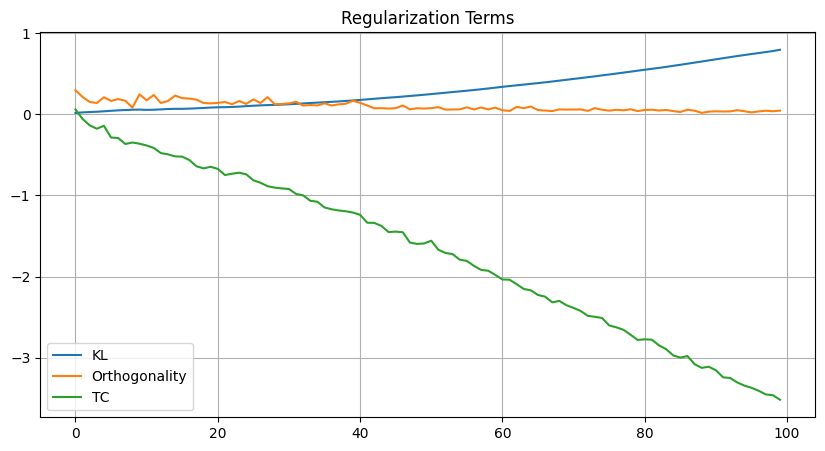

In [62]:
# E7

plt.figure(figsize=(10,5))

plt.plot(
    history["kl"],
    label="KL"
)

plt.plot(
    history["orthogonality"],
    label="Orthogonality"
)

plt.plot(
    history["tc"],
    label="TC"
)

plt.legend()

plt.grid(True)

plt.title(
    "Regularization Terms"
)

plt.show()

In [63]:
# E8

print()

print(
    "Initial Total:",
    history["total"][0]
)

print(
    "Final Total:",
    history["total"][-1]
)

print()

print(
    "Reduction:",
    100
    *
    (
        history["total"][0]
        -
        history["total"][-1]
    )
    /
    history["total"][0],
    "%"
)


Initial Total: 8.776165962219238
Final Total: 3.1089746952056885

Reduction: 64.57479600329346 %


In [64]:
# E9
# Reconstruction Error Audit

with torch.no_grad():

    outputs = model(
        fixed_batch
    )

for feature in [

    "logmel",
    "magnitude",
    "if",
    "modgd"
]:

    mae = (

        outputs[
            "reconstructions"
        ][feature]

        -

        fixed_batch[
            feature
        ]
    ).abs().mean()

    print(
        feature,
        float(mae)
    )

logmel 0.12074599415063858
magnitude 0.12009406834840775
if 0.3632964789867401
modgd 0.7738257050514221
